Import packages and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf

Import Bitcoin daily data

In [2]:
data = yf.download("BTC-USD", start="2023-01-01", interval="1d")

[*********************100%***********************]  1 of 1 completed

YF.download() has changed argument auto_adjust default to True


In [3]:
def getcoin(coin_df):
    # 1. Flatten the MultiIndex (removes the 'BTC-USD' level)
    df_adj = coin_df.copy()
    if isinstance(df_adj.columns, pd.MultiIndex):
        df_adj.columns = df_adj.columns.get_level_values(0)
    
    # 3. Move 'date' from the index to a column
    df_adj = df_adj.reset_index()
    df_adj.rename(columns={'Date': 'Date'}, inplace=True)
    
    # 4. Return specifically in your requested order
    # order: date, close, high, low, open, volume
    return df_adj[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]

Define functions for grid trading strategy

In [4]:
def getcoin(coin_df):
    # 1. Flatten the MultiIndex (removes the 'BTC-USD' level)
    df_adj = coin_df.copy()
    if isinstance(df_adj.columns, pd.MultiIndex):
        df_adj.columns = df_adj.columns.get_level_values(0)
    
    # 2. Lowercase all names to make them consistent
    df_adj.columns = [c for c in df_adj.columns]
    
    # 3. Move 'date' from the index to a column
    df_adj = df_adj.reset_index()
    df_adj.rename(columns={'Date': 'Date'}, inplace=True)
    
    # 4. Return specifically in your requested order
    # order: date, close, high, low, open, volume
    return df_adj[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]



In [5]:
# Usage:
df = getcoin(data)

In [6]:
# Return the list of gridline price
def generategridlinelist(buylowest,sellhighest,linenum):
    grid_diff = round((sellhighest - buylowest)/(linenum-1),8)
    resultlist = []
    priceline = buylowest
    for i in range(linenum):
        resultlist.append(priceline)
        priceline += grid_diff
    return resultlist

In [7]:
# Return the index of current price in the gridline list
def getportionindex(price,gl):
    count = 0
    for i in gl:
        if price != i and price > i :
            count +=1
    if price > gl[-1]:
        count -= 1
    return count

In [8]:
# Return the total value of Bitcoin and cash
def totalasset(Close,stockshare,remain_cash):
    return round(stockshare*Close + remain_cash,2)

In [9]:
#The function returns the price of the grid line price when the close price passes across it, 
#indicating when a price change triggers the trading of Bitcoin for either buying or selling.
def findgridline(close_previous,close_new, gl):
    result = 0
    for l in gl:
        if close_previous < l:
            if close_new < l:
                break
            elif close_new >= l:
                result = l
        elif close_previous == l:
            result = l
        elif close_previous > l:
            if close_new > l:
                continue
            elif close_new <= l:
                result = l
    return result

# Data viewing

In [10]:
# Redefine dataframe of Bitcoin
data = getcoin(data)

In [11]:
# Draw the candle graph
data

,Date,Close,High,Low,Open,Volume
0,2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
1,2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2,2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
3,2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
4,2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566
...,...,...,...,...,...,...
1186,2026-04-01,68078.554688,69230.359375,67555.359375,68232.890625,36465393617
1187,2026-04-02,66888.570312,68633.148438,65725.257812,68077.898438,39323384518
1188,2026-04-03,66931.101562,67296.234375,66281.539062,66889.015625,22815543346
1189,2026-04-04,67290.515625,67515.015625,66769.640625,66938.648438,15878814963


# Grid Strategy Control Table

The user can set up parameters for the strategy and examine the profitiability of the strategy:

1. The upper and lower bound of this strategy is based on the result of Monte Carlo Simulation.

2. The grid line number is based on the frequency of price jumps. I analyze historical price data to identify common price increments and decrements and set your grid lines accordingly. 

3. Initial principal: $30000 

In [12]:
sellhighest = 130000.0
buylowest = 10000.0
gridlinenum = 7
money = 6000

Calculate and assign parameters and list. The oncoinportion means the portion of the initial principal spends on the bitcoin

In [13]:
gridline = generategridlinelist(buylowest,sellhighest,gridlinenum)
#cashportion = [i/(gridlinenum-1) for i in range(0,gridlinenum)]
oncoinportion = [1-i/(gridlinenum-1)for i in range(0,gridlinenum)]
#cashportionlist = [i* money for i in cashportion]
oncoinportionlist = [i* money for i in oncoinportion]

In [14]:
gridline

[10000.0, 30000.0, 50000.0, 70000.0, 90000.0, 110000.0, 130000.0]

In [15]:
oncoinportion

[1.0,
 0.8333333333333334,
 0.6666666666666667,
 0.5,
 0.33333333333333337,
 0.16666666666666663,
 0.0]

In [16]:
getportionindex(10000, gridline)

0

In [17]:
findgridline(130001,140000, gridline)

0

In [18]:
np.linspace(buylowest,sellhighest,gridlinenum)

array([ 10000.,  30000.,  50000.,  70000.,  90000., 110000., 130000.])

In [19]:
#Close price of the bitcoin
dftest = pd.DataFrame(data).reindex(columns=['Close'])#columns=[ 'Open', 'Close']
dftest

,Close
0,16625.080078
1,16688.470703
2,16679.857422
3,16863.238281
4,16836.736328
...,...
1186,68078.554688
1187,66888.570312
1188,66931.101562
1189,67290.515625


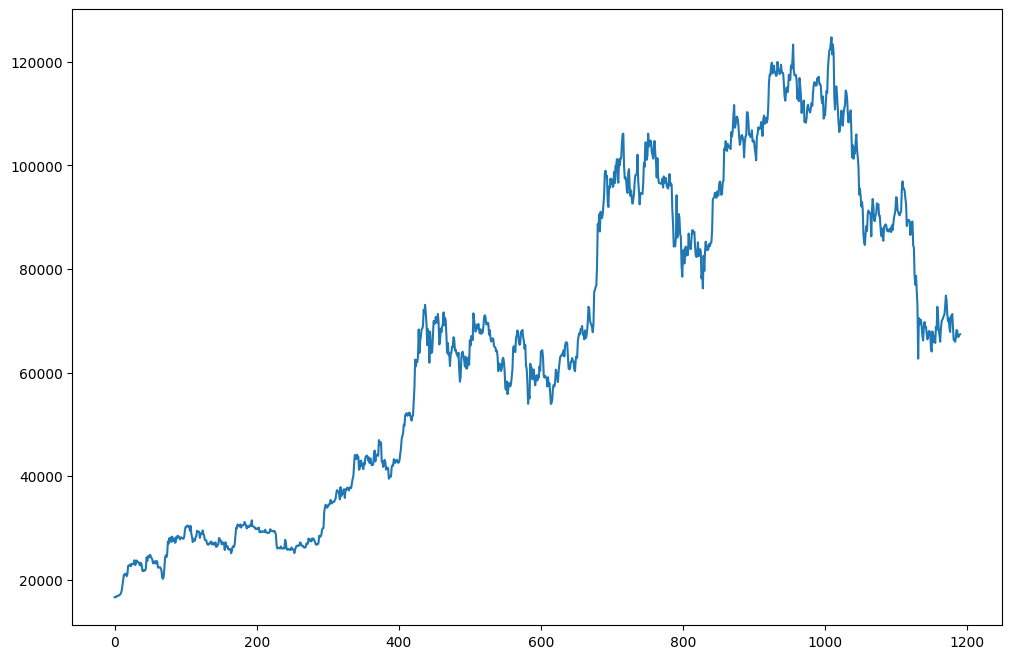

In [20]:
plt.figure(figsize=(12,8))
plt.plot(dftest)

In [21]:
# Coinprice list shows the price that the close price just passed in two rows of time tick.
# Initialize an empty list to store the grid line price or 0 if no grid line was passed.
coinprice = []

# Check if the close price at the first row (index 0) of dftest is in the gridline list.
# If it is, append the close price to the coinprice list; otherwise, append 0.
if dftest.Close[0] in gridline:
    coinprice.append(dftest.Close[0])
else:
    coinprice.append(0)

# Loop through the rows in dftest, starting from index 1.
for i in range(1, len(dftest)):
    # Call the findgridline function with the close price from the previous row and the current close price.
    # Append the result to the coinprice list.
    coinprice.append(findgridline(dftest.Close[i - 1], dftest.Close[i], gridline))

# Add a new column 'Coin_Price' to the dftest DataFrame, containing the values from the coinprice list.
dftest['Coin_Price'] = coinprice


In [22]:
oncoin = []  # List to track how much money is invested in cryptocurrency
cashflow_oncoin = []  # List to track cash flow related to cryptocurrency
coinnum = []  # List to track the number of coins held
lastoc = 0  # Last value of on-coin cash
lastcoinnum = 0  # Last value of coin number (cash divided by price)
cash = []  # List to track the available cash
startposition = 0  # Flag to indicate the starting position (0 for not started, 1 for started)
commission = 0.004  # Commission rate for buying/selling

# Iterate through the Coin_Price values in the DataFrame dftest
for i in dftest.Coin_Price:
    if i == 0:
        if startposition == 0:
            # If no coins are held, record 0 for on-coin cash, cash flow, coin number, and available cash
            oncoin.append(0)
            cashflow_oncoin.append(0)
            coinnum.append(0)
            cash.append(money)
        else:
            # If there's a position but the Coin_Price is 0, record the on-coin portion, cash flow, coin number,
            # and available cash
            oncoin.append(oncoinportionlist[portion])
            cashflow_oncoin.append(0)
            coinnum.append(lastcoinnum)
            cash.append(money)
    else:
        # Calculate values when there's a Coin_Price
        portion = getportionindex(i, gridline)  # Calculate the portion based on the grid line

        # On-coin cash
        oncoin.append(oncoinportionlist[portion])

        # Cash Flow
        if i != lastoc:
            tempcash = oncoinportionlist[portion] - lastoc
            cashflow_oncoin.append(tempcash)
            lastoc = oncoinportionlist[portion]
        else:
            cashflow_oncoin.append(0)

        # Coin Number
        if startposition == 0:
            # Calculate the initial coin number when starting a position
            lastcoinnum = round(oncoinportionlist[portion] * (1 - commission) / i, 8)
            coinnum.append(lastcoinnum)
        else:
            if i != lastoc:
                if tempcash > 0:
                    # Buy coin
                    lastcoinnum = round(tempcash * (1 - commission) / i, 8) + lastcoinnum
                    coinnum.append(lastcoinnum)
                else:
                    # Sell coin (with commission)
                    lastcoinnum = round(tempcash * (1 + commission) / i, 8) + lastcoinnum
                    coinnum.append(lastcoinnum)
            else:
                coinnum.append(lastcoinnum)

        # Cash
        if startposition == 0:
            money -= oncoinportionlist[portion]
            cash.append(money)
        else:
            if i != lastoc:
                money -= tempcash
                cash.append(money)
            else:
                cash.append(money)

        # Set the start position flag to 1 (indicating that the trading has started)
        startposition = 1

In [23]:
# Set up columns for dataframe
dftest['On_Coin'] = oncoin
dftest['CF_On_Coin'] = cashflow_oncoin
dftest["Coin_Num"] = coinnum
dftest["Cash"] = cash

In [24]:
# Print the number of trading times in this period
# It counts the rows in the DataFrame 'dftest' where the 'CF_On_Coin' column is not equal to 0.
# This indicates the number of times a trade was made.
print("How many trading times in this period? Ans: ", len(dftest[dftest['CF_On_Coin'] != 0]))

How many trading times in this period? Ans:  7


In [25]:
#List out the trading records
dftest[dftest['CF_On_Coin'] != 0]

,Close,Coin_Price,On_Coin,CF_On_Coin,Coin_Num,Cash
100,30235.058594,30000.0,5000.0,5000.0,0.166000,1000.0
409,51826.695312,50000.0,4000.0,-1000.0,0.145920,2000.0
435,72123.906250,70000.0,3000.0,-1000.0,0.131577,3000.0
682,90584.164062,90000.0,2000.0,-1000.0,0.120422,4000.0
872,111673.281250,110000.0,1000.0,-1000.0,0.111294,5000.0
1054,86631.898438,90000.0,2000.0,1000.0,0.122361,4000.0
1131,62702.097656,70000.0,3000.0,1000.0,0.136590,3000.0


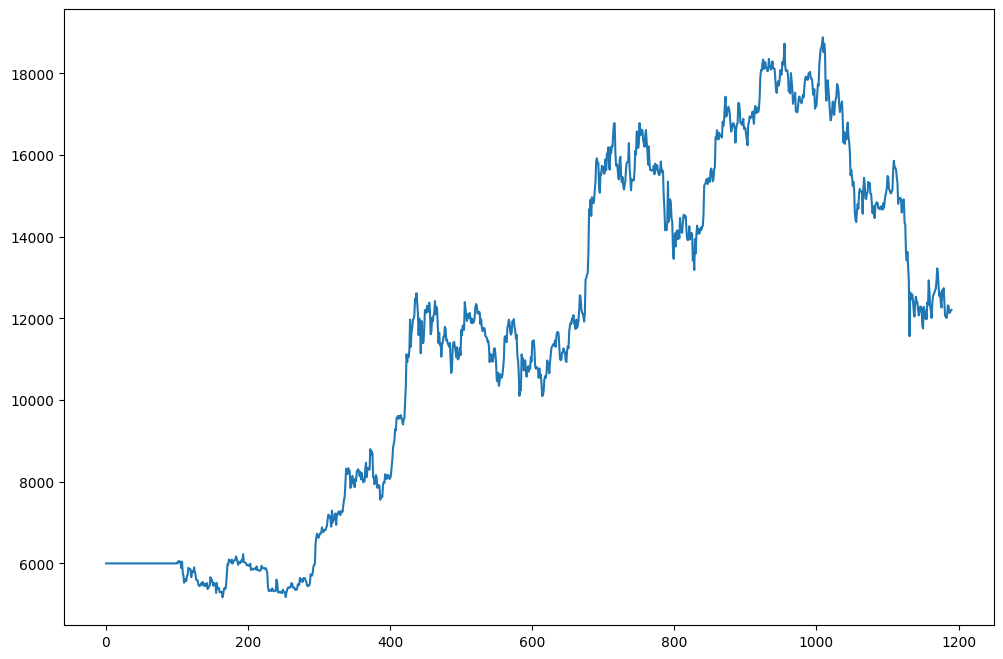

In [26]:
#dftest
plt.figure(figsize=(12,8))
plt.plot(totalasset(dftest.Close,dftest.Coin_Num,dftest.Cash))

In [27]:
# The latest total asset value
latestAssetValue = totalasset(dftest.Close,dftest.Coin_Num,dftest.Cash).iloc[-1]
latestAssetValue

np.float64(12207.13)

In [28]:
#The return rate since 2023 for grid trading strategy
print("The return rate is " + str(round((latestAssetValue/ money - 1)*100,2)) + "%")


The return rate is 306.9%
